<a href="https://colab.research.google.com/github/SharuNivetha06/Autoencoder/blob/main/AE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim_fn

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

N_TRAIN, N_TEST = 10_000, 2_000
EPOCHS, EPOCHS_VAE = 20, 30
BATCH, LR = 128, 1e-3

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
(x_all, y_all), (x_te, y_te) = keras.datasets.mnist.load_data()

x_all = (x_all[:N_TRAIN].astype("float32") / 255.0)[..., None]
x_test = (x_te[:N_TEST].astype("float32") / 255.0)[..., None]
y_test = y_te[:N_TEST]

x_fit, x_val = x_all[:9000], x_all[9000:]

flat = lambda a: a.reshape(len(a), -1)
print("fit:", x_fit.shape, "val:", x_val.shape, "test:", x_test.shape,
      "| pixel range:", x_fit.min(), "-", x_fit.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
fit: (9000, 28, 28, 1) val: (1000, 28, 28, 1) test: (2000, 28, 28, 1) | pixel range: 0.0 - 1.0


In [3]:
results = {}
times = {}

def evaluate_recon(x, xh):
    x = x.reshape(-1, 28, 28, 1); xh = xh.reshape(-1, 28, 28, 1)
    mse = float(np.mean((x - xh) ** 2))
    mae = float(np.mean(np.abs(x - xh)))
    s = np.mean([ssim_fn(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xh)])
    return {"MSE": mse, "MAE": mae, "SSIM": float(s)}

def show_recon(x, xh, n=10, title=""):
    x = x.reshape(-1, 28, 28); xh = xh.reshape(-1, 28, 28)
    fig, ax = plt.subplots(3, n, figsize=(1.4 * n, 4.6))
    for i in range(n):
        for r, (img, cm) in enumerate([(x[i], "gray"), (xh[i], "gray"), (np.abs(x[i] - xh[i]), "hot")]):
            ax[r, i].imshow(img, cmap=cm, vmin=0, vmax=1); ax[r, i].axis("off")
    for r, name in enumerate(["Original", "Reconstruction", "|Error|"]):
        ax[r, 0].set_title(name, loc="left", fontsize=9)
    fig.suptitle(title); plt.tight_layout(); plt.show()

def plot_history(h, title, keys=("loss", "val_loss"), ylabel="Reconstruction loss"):
    plt.figure(figsize=(6, 4))
    for k, lab in zip(keys, ["Training loss", "Validation loss"]):
        plt.plot(h[k] if isinstance(h, dict) else h.history[k], label=lab)
    plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.title(title); plt.legend(); plt.show()

def fit_timed(model, x, y, **kw):
    t0 = time.time(); h = model.fit(x, y, verbose=0, **kw); return h, time.time() - t0

In [4]:
def build_fc_ae(latent_dim=16):
    inp = keras.Input((784,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(784, activation="sigmoid")(x)
    m = keras.Model(inp, out, name=f"fc_ae_{latent_dim}")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="binary_crossentropy")
    return m

fc_ae = build_fc_ae(16)
fc_ae.summary()

h_fc, t = fit_timed(fc_ae, flat(x_fit), flat(x_fit), epochs=EPOCHS, batch_size=BATCH,
                    shuffle=True, validation_data=(flat(x_val), flat(x_val)))
times["FC AE"] = t
xh_fc = fc_ae.predict(flat(x_test), verbose=0).reshape(-1, 28, 28, 1)
m = evaluate_recon(x_test, xh_fc)
results["FC Autoencoder"] = {**m, "Params": fc_ae.count_params(), "Time (s)": t}
print(pd.Series(m).round(5), f"\ntraining time: {t:.1f}s")

Model: "fc_ae_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

MSE     0.02049
MAE     0.05540
SSIM    0.75777
dtype: float64 
training time: 15.7s


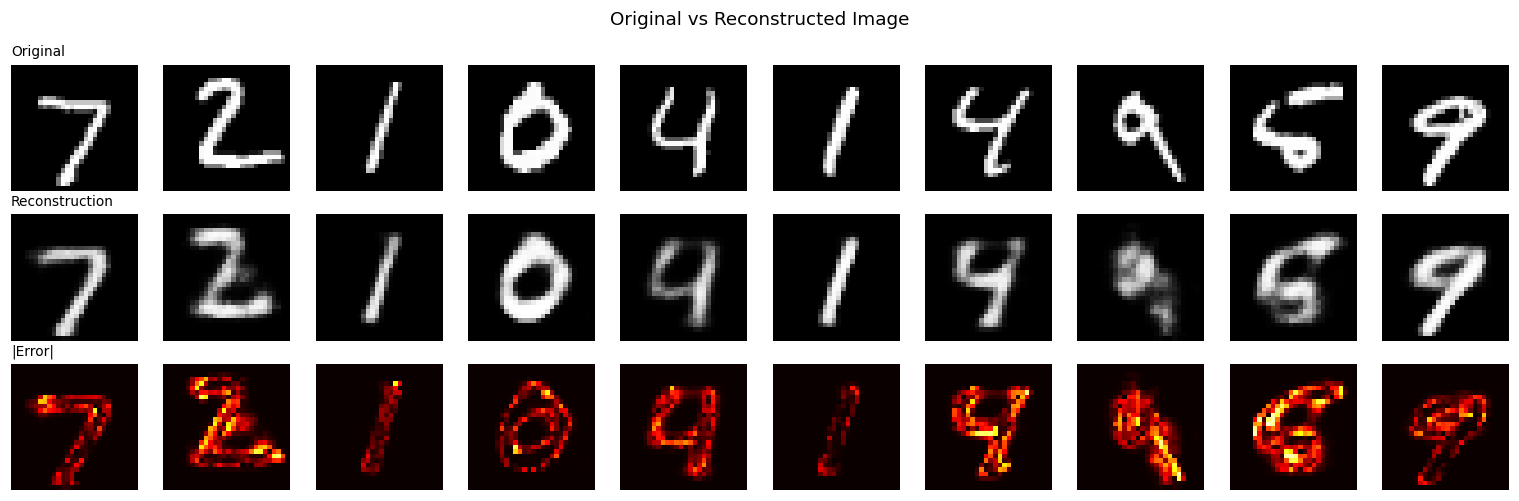

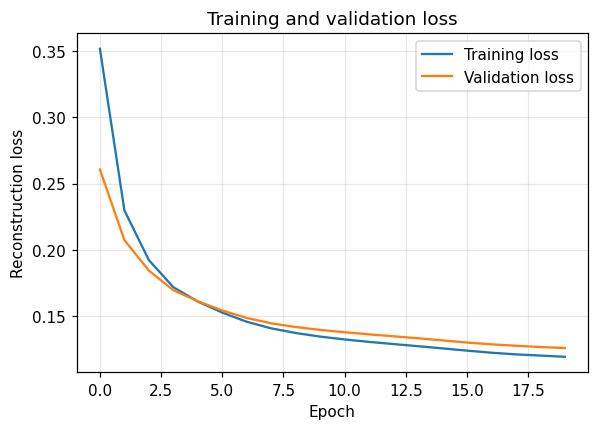

final train loss 0.1196 | final val loss 0.1262 | best val epoch 20


In [5]:
show_recon(x_test, xh_fc, n=10, title="Original vs Reconstructed Image")

plot_history(h_fc, "Training and validation loss")
print(f"final train loss {h_fc.history['loss'][-1]:.4f} | final val loss {h_fc.history['val_loss'][-1]:.4f} "
      f"| best val epoch {int(np.argmin(h_fc.history['val_loss'])) + 1}")

Model: "cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

MSE     0.00259
MAE     0.01504
SSIM    0.97377
dtype: float64 
training time: 19.4s


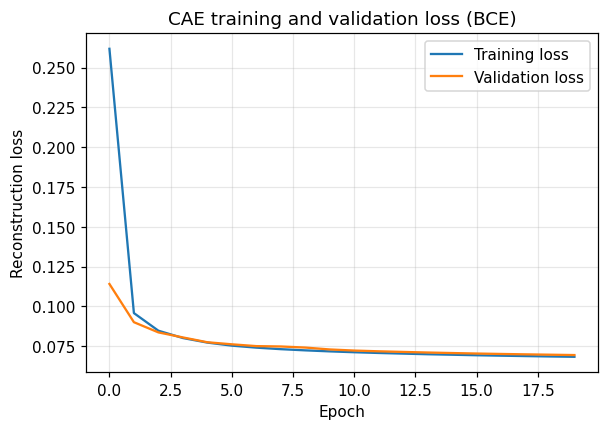

In [6]:
def build_cae(latent_dim=None):
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    if latent_dim is not None:
        x = layers.Flatten()(x)
        x = layers.Dense(latent_dim, name="latent")(x)
        x = layers.Dense(7 * 7 * 64, activation="relu")(x)
        x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    m = keras.Model(inp, out, name="cae" if latent_dim is None else f"cae_{latent_dim}")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="binary_crossentropy")
    return m

cae = build_cae()
cae.summary()
h_cae, t = fit_timed(cae, x_fit, x_fit, epochs=EPOCHS, batch_size=BATCH, shuffle=True,
                     validation_data=(x_val, x_val))
times["CAE"] = t
xh_cae = cae.predict(x_test, verbose=0)
m = evaluate_recon(x_test, xh_cae)
results["Conv. Autoencoder"] = {**m, "Params": cae.count_params(), "Time (s)": t}
print(pd.Series(m).round(5), f"\ntraining time: {t:.1f}s")
plot_history(h_cae, "CAE training and validation loss (BCE)")

,MSE,MAE,SSIM,Params
FC Autoencoder,0.02049,0.05540,0.75777,211040.0
Conv. Autoencoder,0.00259,0.01504,0.97377,74497.0


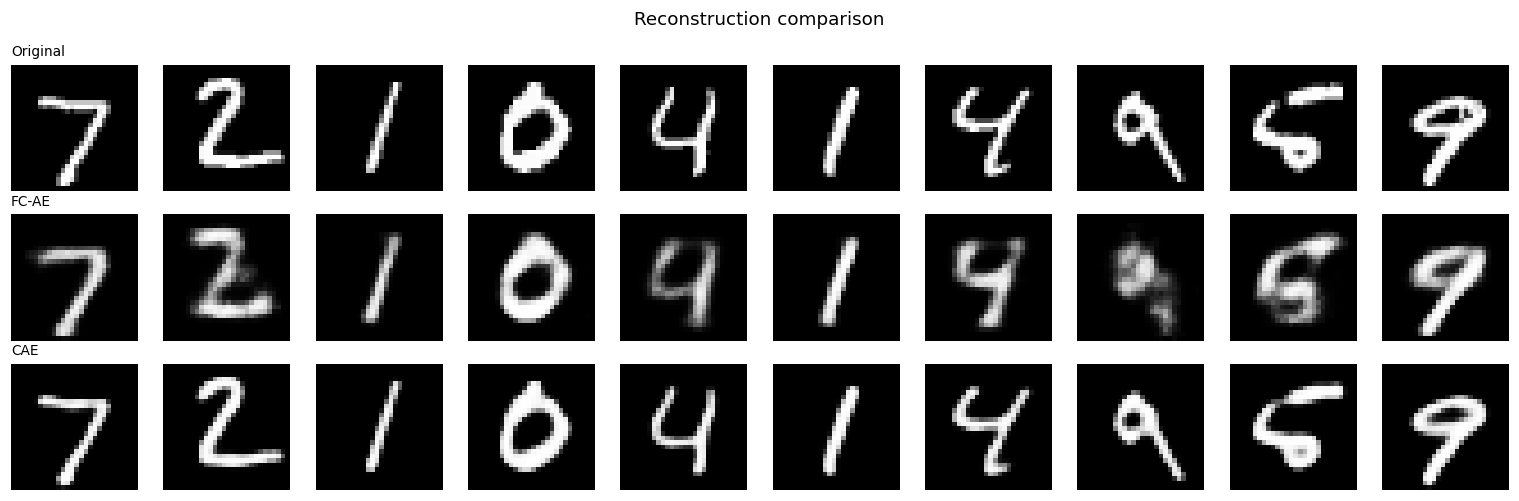

In [7]:
cmp = pd.DataFrame({k: results[k] for k in ["FC Autoencoder", "Conv. Autoencoder"]}).T[["MSE", "MAE", "SSIM", "Params"]]
display(cmp.round(5))

n = 10
fig, ax = plt.subplots(3, n, figsize=(1.4 * n, 4.6))
for i in range(n):
    for r, img in enumerate([x_test[i], xh_fc[i], xh_cae[i]]):
        ax[r, i].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); ax[r, i].axis("off")
for r, name in enumerate(["Original", "FC-AE", "CAE"]):
    ax[r, 0].set_title(name, loc="left", fontsize=9)
fig.suptitle("Reconstruction comparison"); plt.tight_layout(); plt.show()

In [8]:
def add_gaussian(x, sigma, rng):
    return np.clip(x + rng.normal(0.0, sigma, x.shape), 0.0, 1.0).astype("float32")

def add_salt_pepper(x, p, rng):
    x = x.copy(); r = rng.random(x.shape)
    x[r < p / 2] = 0.0
    x[(r >= p / 2) & (r < p)] = 1.0
    return x

def train_dae(noise_fn, level, epochs=EPOCHS, seed=0):
    rng = np.random.default_rng(seed)
    m = build_cae()
    xv_noisy = noise_fn(x_val, level, np.random.default_rng(123))
    hist = {"loss": [], "val_loss": []}
    t0 = time.time()
    for _ in range(epochs):
        xn = noise_fn(x_fit, level, rng)
        h = m.fit(xn, x_fit, epochs=1, batch_size=BATCH, shuffle=True,
                  validation_data=(xv_noisy, x_val), verbose=0)
        hist["loss"].append(h.history["loss"][0]); hist["val_loss"].append(h.history["val_loss"][0])
    return m, hist, time.time() - t0

GAUSS_LEVELS = [0.1, 0.2, 0.3]
SP_LEVELS = [0.05, 0.10, 0.20]
dae_g = {s: train_dae(add_gaussian, s) for s in GAUSS_LEVELS}
dae_sp = {p: train_dae(add_salt_pepper, p) for p in SP_LEVELS}
print("trained", len(dae_g) + len(dae_sp), "denoising models")

trained 6 denoising models


In [9]:
def eval_dae(models, noise_fn, levels):
    rows, cache = [], {}
    for lv in levels:
        m, hist, t = models[lv]
        xn = noise_fn(x_test, lv, np.random.default_rng(999))
        xd = m.predict(xn, verbose=0)
        d, base = evaluate_recon(x_test, xd), evaluate_recon(x_test, xn)
        rows.append({"Noise level": lv, **d, "Noisy-input MSE": base["MSE"],
                     "Noisy-input MAE": base["MAE"], "Noisy-input SSIM": base["SSIM"]})
        cache[lv] = (xn, xd)
    return pd.DataFrame(rows).set_index("Noise level"), cache

tab_g, cache_g = eval_dae(dae_g, add_gaussian, GAUSS_LEVELS)
tab_sp, cache_sp = eval_dae(dae_sp, add_salt_pepper, SP_LEVELS)
print("Gaussian noise (sigma)"); display(tab_g.round(5))
print("Salt-and-pepper noise (p)"); display(tab_sp.round(5))

mm, hh, tt = dae_g[0.2]
results["Denoising CAE (sigma=0.2)"] = {**tab_g.loc[0.2, ["MSE", "MAE", "SSIM"]].to_dict(),
                                        "Params": mm.count_params(), "Time (s)": tt}

Gaussian noise (sigma)


,MSE,MAE,SSIM,Noisy-input MSE,Noisy-input MAE,Noisy-input SSIM
Noise level,,,,,,
0.1,0.00331,0.01745,0.96319,0.00543,0.04409,0.67893
0.2,0.00437,0.02054,0.94758,0.02122,0.08665,0.59384
0.3,0.00667,0.02627,0.91713,0.04668,0.12812,0.50924


Salt-and-pepper noise (p)


,MSE,MAE,SSIM,Noisy-input MSE,Noisy-input MAE,Noisy-input SSIM
Noise level,,,,,,
0.05,0.00381,0.01841,0.95751,0.02399,0.02491,0.70923
0.10,0.00489,0.02123,0.94443,0.04809,0.04994,0.57906
0.20,0.00749,0.02740,0.91309,0.09635,0.10005,0.44708


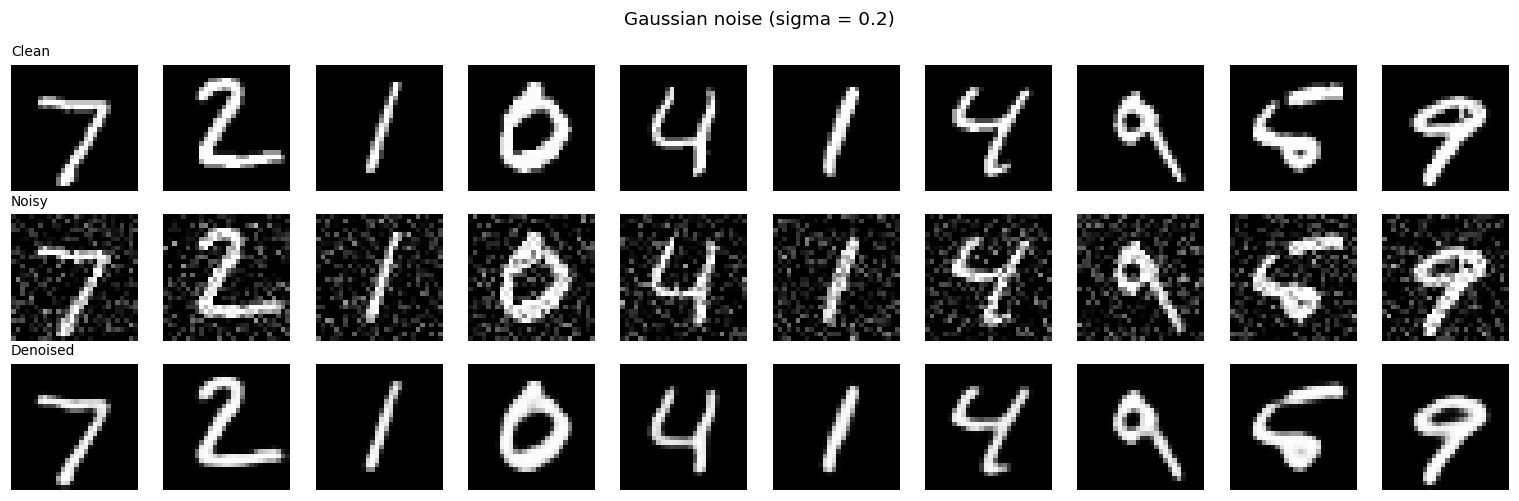

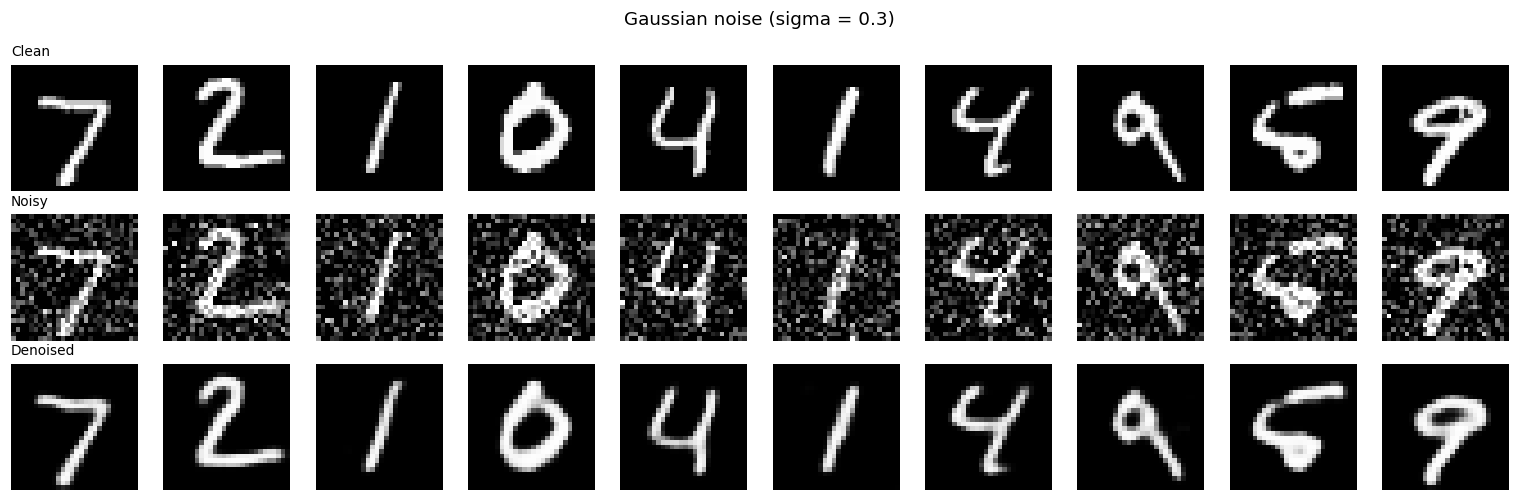

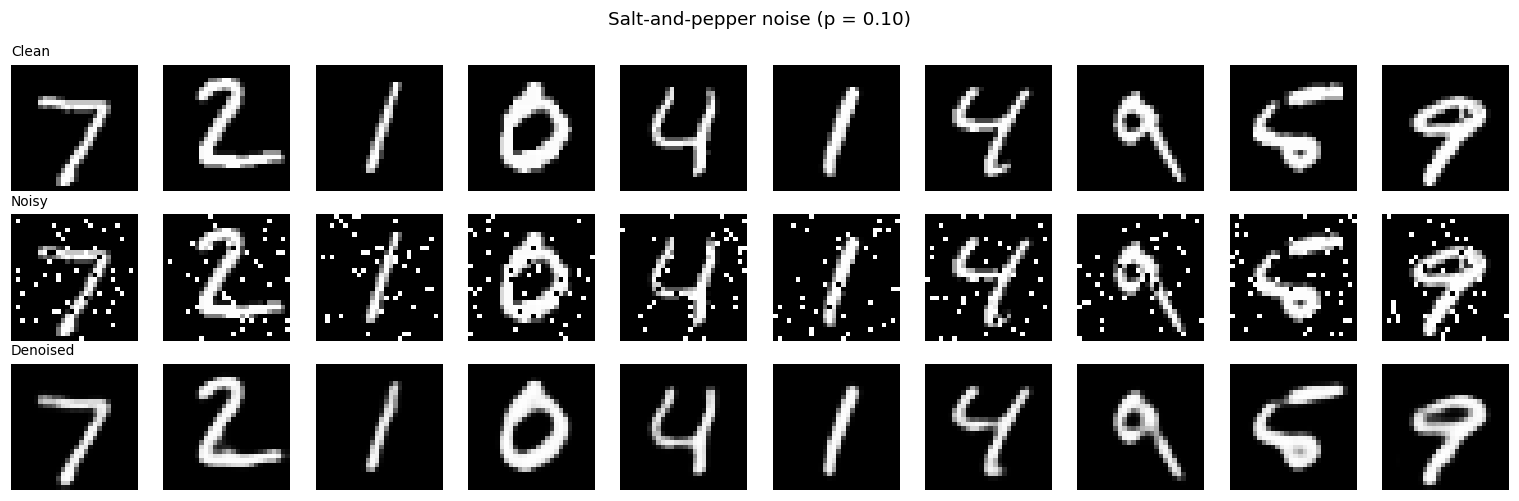

In [10]:
def show_triplet(clean, noisy, den, n=10, title=""):
    fig, ax = plt.subplots(3, n, figsize=(1.4 * n, 4.6))
    for i in range(n):
        for r, img in enumerate([clean[i], noisy[i], den[i]]):
            ax[r, i].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); ax[r, i].axis("off")
    for r, name in enumerate(["Clean", "Noisy", "Denoised"]):
        ax[r, 0].set_title(name, loc="left", fontsize=9)
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_triplet(x_test, *cache_g[0.2], title="Gaussian noise (sigma = 0.2)")
show_triplet(x_test, *cache_g[0.3], title="Gaussian noise (sigma = 0.3)")
show_triplet(x_test, *cache_sp[0.10], title="Salt-and-pepper noise (p = 0.10)")

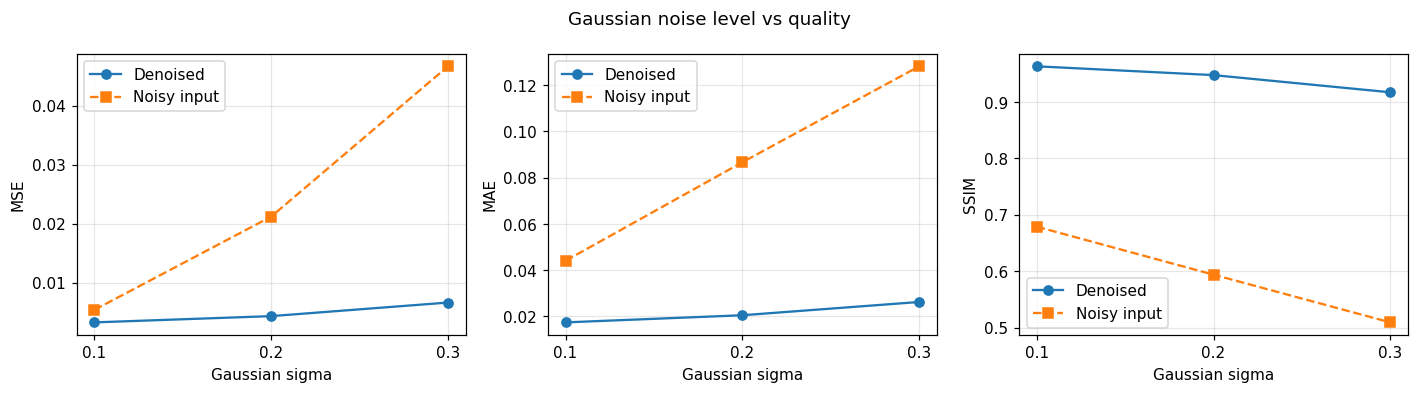

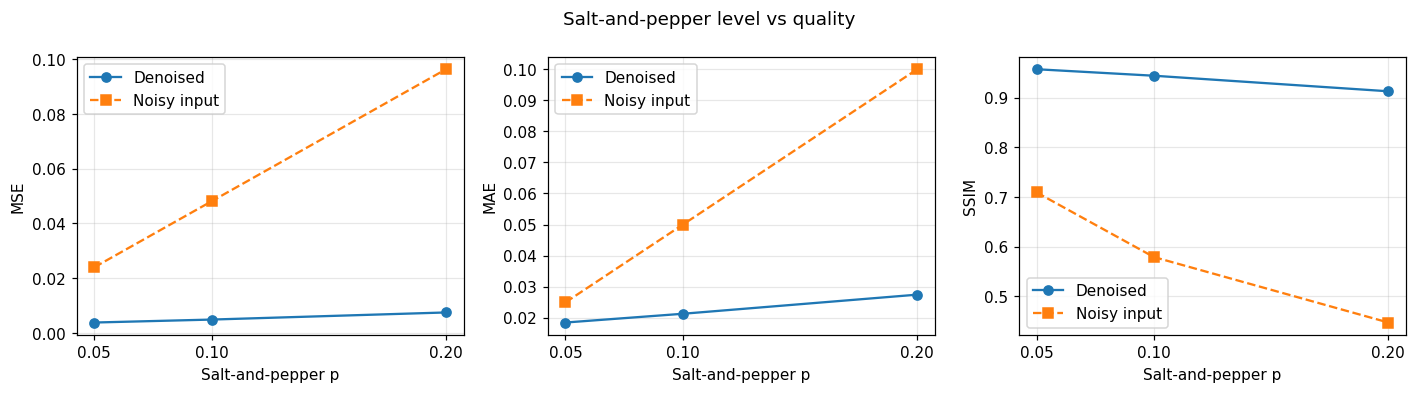

In [11]:
def plot_noise_curves(tab, xlabel, title):
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
    for a, met in zip(ax, ["MSE", "MAE", "SSIM"]):
        a.plot(tab.index, tab[met], "o-", label="Denoised")
        a.plot(tab.index, tab[f"Noisy-input {met}"], "s--", label="Noisy input")
        a.set_xlabel(xlabel); a.set_ylabel(met); a.set_xticks(tab.index); a.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_noise_curves(tab_g, "Gaussian sigma", "Gaussian noise level vs quality")
plot_noise_curves(tab_sp, "Salt-and-pepper p", "Salt-and-pepper level vs quality")

In [12]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps

def build_encoder(latent_dim=2):
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inp)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    mu = layers.Dense(latent_dim, name="mu")(x)
    log_var = layers.Dense(latent_dim, name="log_var")(x)
    z = Sampling()([mu, log_var])
    return keras.Model(inp, [mu, log_var, z], name="encoder")

def build_decoder(latent_dim=2):
    inp = keras.Input((latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(inp)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    out = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(inp, out, name="decoder")

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder, self.beta = encoder, decoder, beta
        self.total_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec_loss")
        self.kl_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(x)
            xh = self.decoder(z)
            rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xh), axis=(1, 2)))
            kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1))
            total = rec + self.beta * kl
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_tracker.update_state(total); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        mu, log_var, z = self.encoder(x)
        xh = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xh), axis=(1, 2)))
        kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1))
        total = rec + self.beta * kl
        self.total_tracker.update_state(total); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

def train_vae(latent_dim=2, beta=1.0, epochs=EPOCHS_VAE):
    enc, dec = build_encoder(latent_dim), build_decoder(latent_dim)
    v = VAE(enc, dec, beta=beta)
    v.compile(optimizer=keras.optimizers.Adam(LR))
    t0 = time.time()
    h = v.fit(x_fit, x_fit, epochs=epochs, batch_size=BATCH, shuffle=True,
              validation_data=(x_val, x_val), verbose=0)
    return v, h, time.time() - t0

vae, h_vae, t_vae = train_vae(2, 1.0)
times["VAE"] = t_vae
print(f"training time: {t_vae:.1f}s | final train loss {h_vae.history['loss'][-1]:.2f} "
      f"| final val loss {h_vae.history['val_loss'][-1]:.2f}")
vae.encoder.summary(); vae.decoder.summary()

training time: 26.6s | final train loss 148.58 | final val loss 153.28


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        258 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        258 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

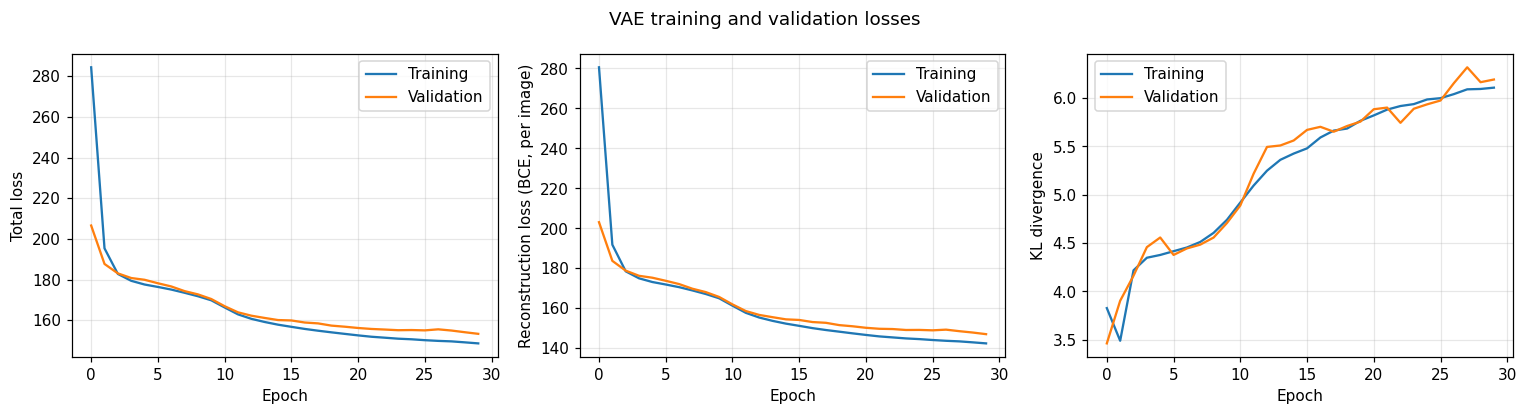

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, (k, name) in zip(ax, [("loss", "Total loss"), ("rec_loss", "Reconstruction loss (BCE, per image)"), ("kl_loss", "KL divergence")]):
    a.plot(h_vae.history[k], label="Training"); a.plot(h_vae.history[f"val_{k}"], label="Validation")
    a.set_xlabel("Epoch"); a.set_ylabel(name); a.legend()
fig.suptitle("VAE training and validation losses"); plt.tight_layout(); plt.show()

,Value
Reconstruction loss,147.3410
KL loss,6.0585
Total loss,153.3996
Test MSE,0.0428
Test MAE,0.0998
Test SSIM,0.5030


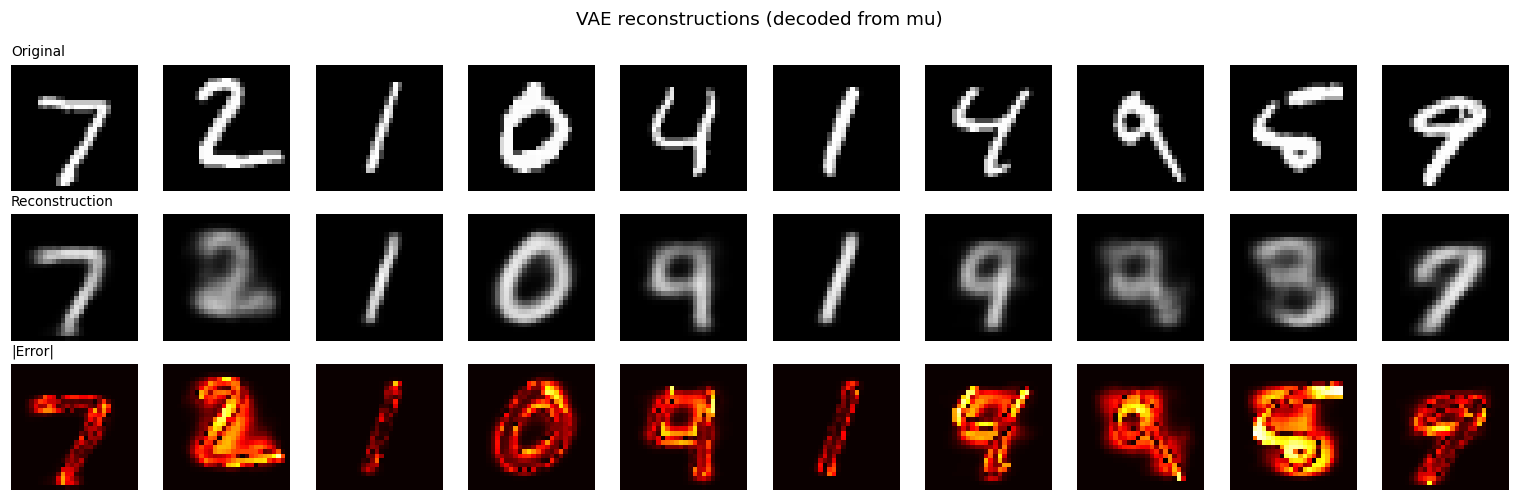

In [14]:
mu_te, lv_te, _ = vae.encoder.predict(x_test, verbose=0)
xh_vae = vae.decoder.predict(mu_te, verbose=0)
m = evaluate_recon(x_test, xh_vae)
ev = vae.evaluate(x_test, x_test, verbose=0, return_dict=True)
vae_tab = pd.Series({"Reconstruction loss": ev["rec_loss"], "KL loss": ev["kl_loss"], "Total loss": ev["loss"], **{f"Test {k}": v for k, v in m.items()}})
display(vae_tab.round(4).to_frame("Value"))
results["VAE"] = {**m, "Params": vae.encoder.count_params() + vae.decoder.count_params(), "Time (s)": t_vae}

show_recon(x_test, xh_vae, n=10, title="VAE reconstructions (decoded from mu)")

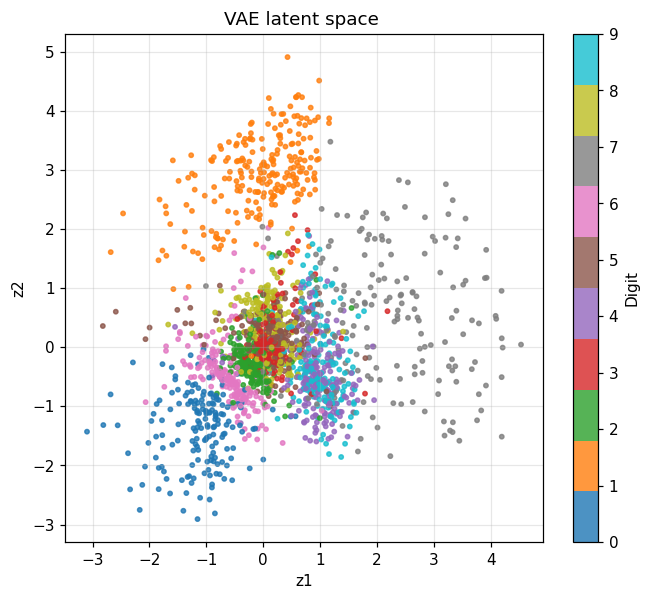

mean posterior sigma per dim: [0.061 0.066] | std of mu per dim: [1.004 1.261]


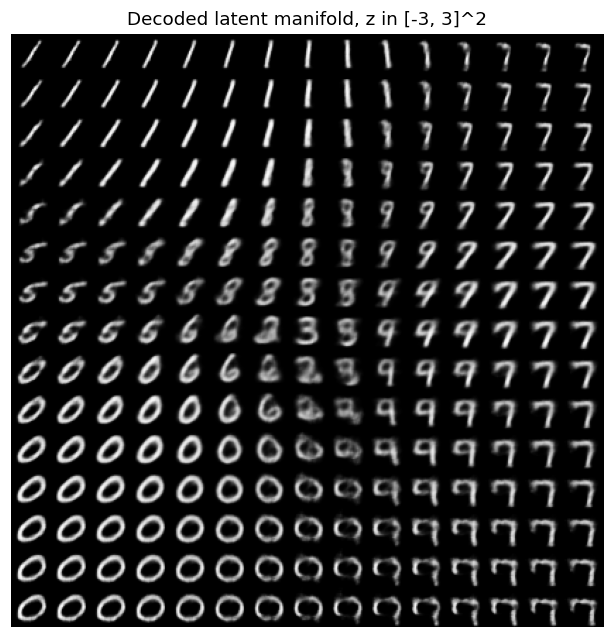

In [15]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(mu_te[:, 0], mu_te[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.8)
plt.colorbar(sc, ticks=range(10), label="Digit"); plt.xlabel("z1"); plt.ylabel("z2")
plt.title("VAE latent space "); plt.show()
print("mean posterior sigma per dim:", np.exp(0.5 * lv_te).mean(0).round(3), "| std of mu per dim:", mu_te.std(0).round(3))

g = np.linspace(-3, 3, 15)
grid = np.array([[a, b] for b in g[::-1] for a in g], dtype="float32")
imgs = vae.decoder.predict(grid, verbose=0).reshape(15, 15, 28, 28)
canvas = imgs.transpose(0, 2, 1, 3).reshape(15 * 28, 15 * 28)
plt.figure(figsize=(7, 7)); plt.imshow(canvas, cmap="gray"); plt.axis("off")
plt.title("Decoded latent manifold, z in [-3, 3]^2"); plt.show()

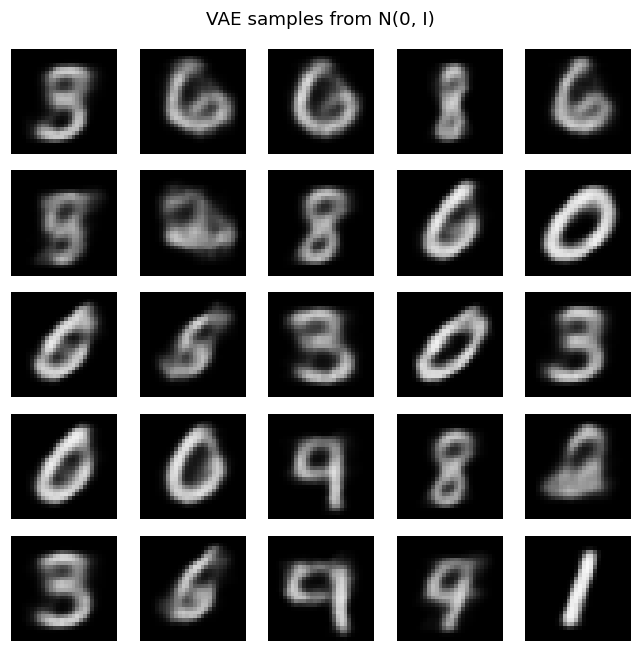

In [16]:
rng = np.random.default_rng(7)
z = rng.normal(size=(25, 2)).astype("float32")
gen = vae.decoder.predict(z, verbose=0)
fig, ax = plt.subplots(5, 5, figsize=(6, 6))
for a, img in zip(ax.ravel(), gen):
    a.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); a.axis("off")
fig.suptitle("VAE samples from N(0, I)"); plt.tight_layout(); plt.show()

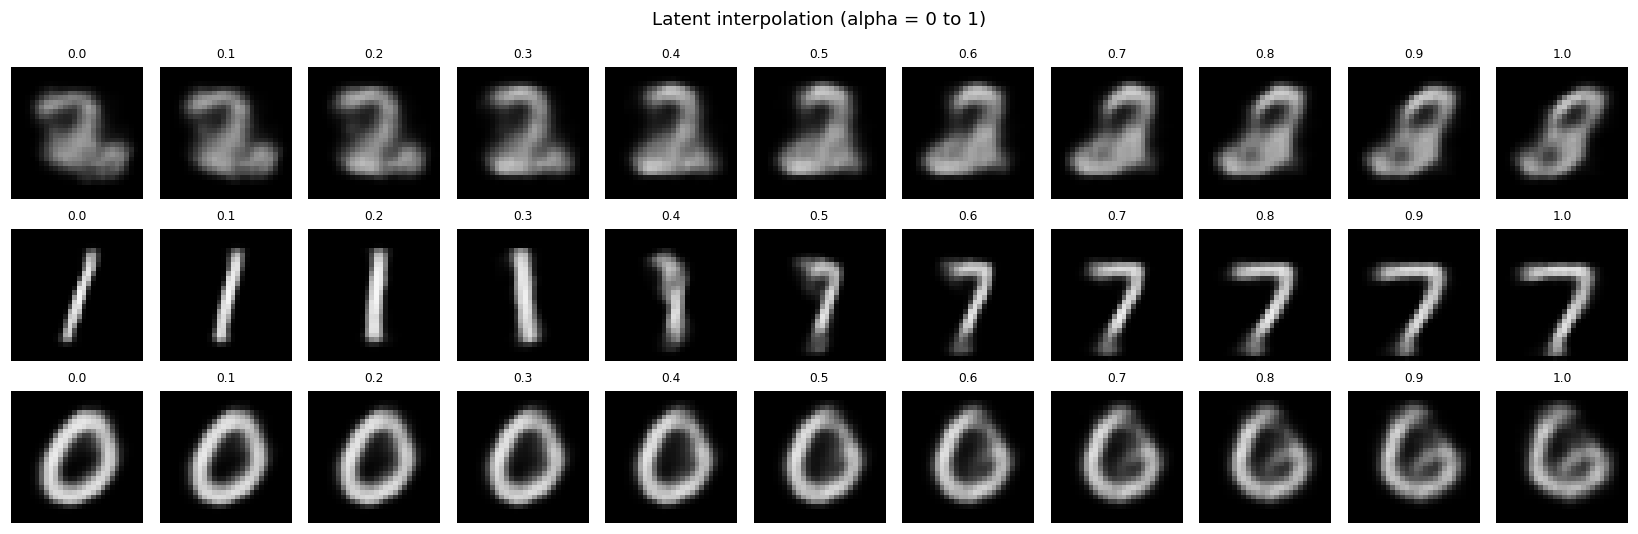

In [17]:
def interpolate(d_a, d_b, steps=11):
    ia, ib = np.where(y_test == d_a)[0][0], np.where(y_test == d_b)[0][0]
    zA, zB = mu_te[ia], mu_te[ib]
    alphas = np.linspace(0, 1, steps)
    zs = np.array([(1 - a) * zA + a * zB for a in alphas], dtype="float32")
    return alphas, vae.decoder.predict(zs, verbose=0)

fig, axes = plt.subplots(3, 11, figsize=(15, 5))
for row, (a, b) in zip(axes, [(3, 8), (1, 7), (0, 6)]):
    alphas, imgs = interpolate(a, b)
    for j, (al, img) in enumerate(zip(alphas, imgs)):
        row[j].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); row[j].axis("off")
        row[j].set_title(f"{al:.1f}", fontsize=8)
    row[0].set_ylabel(f"{a} to {b}")
fig.suptitle("Latent interpolation (alpha = 0 to 1)"); plt.tight_layout(); plt.show()

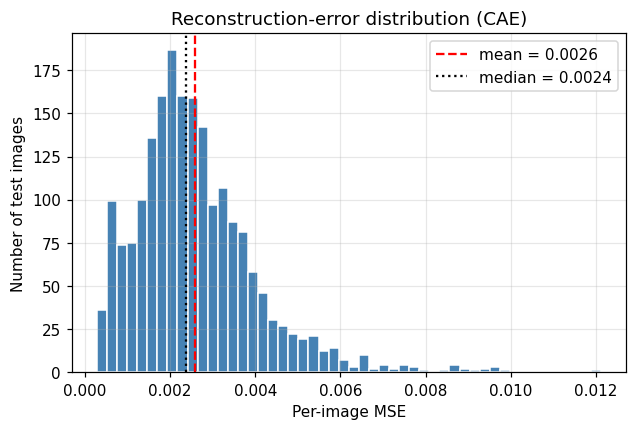

CAE | min/5%/50%/95%/max: [0.00028 0.00065 0.00236 0.00523 0.01211]


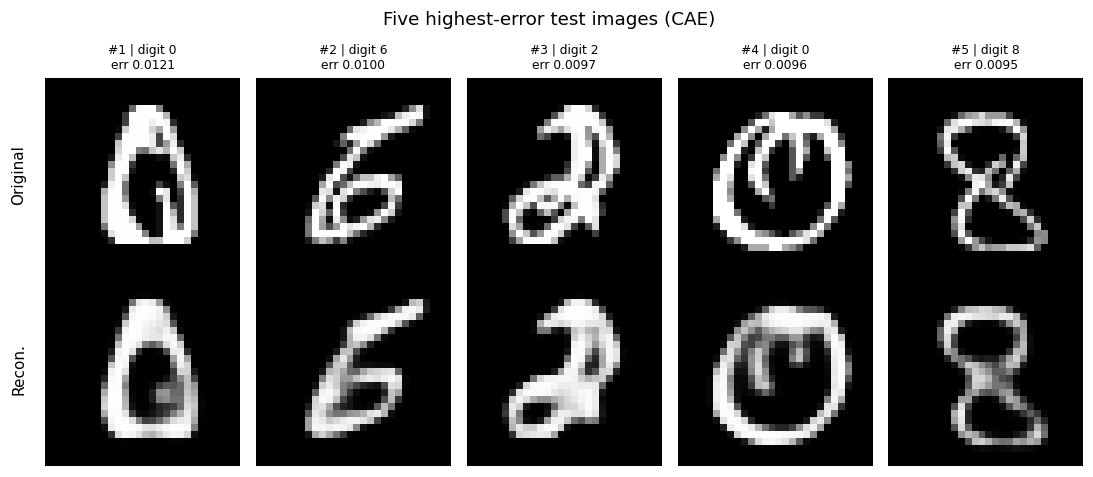

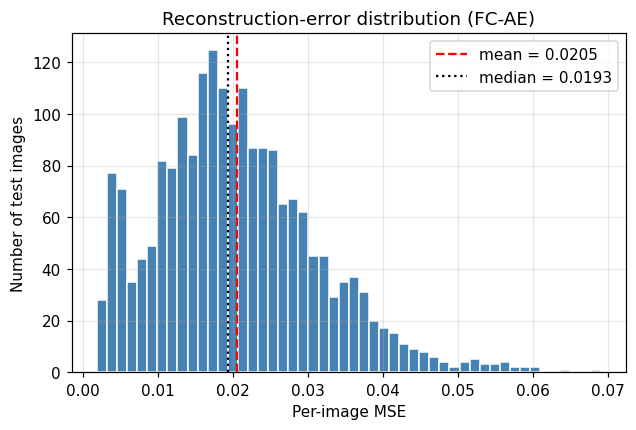

FC-AE | min/5%/50%/95%/max: [0.00183 0.00446 0.01932 0.03934 0.06907]


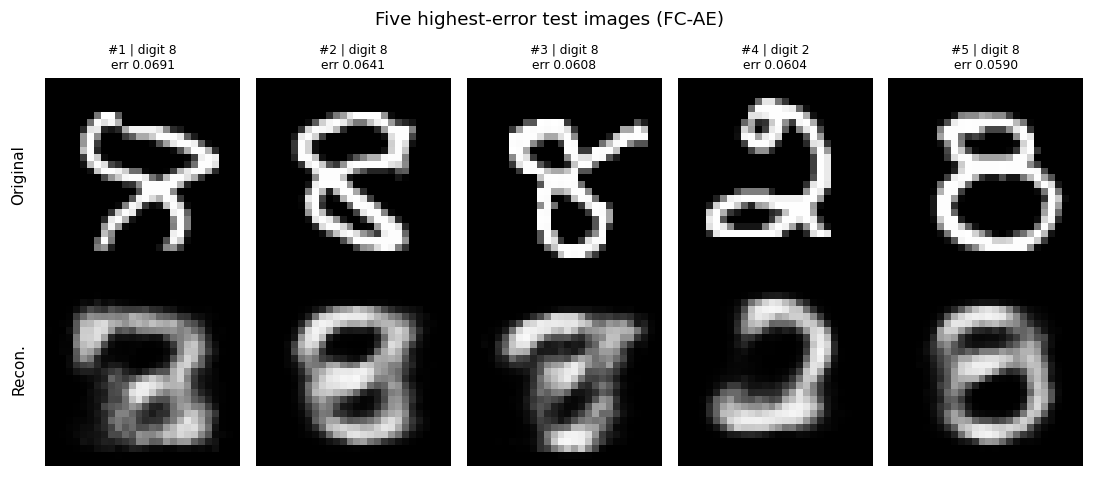

In [18]:
def analyze_errors(x, xh, name, top_k=5):
    e = np.mean((x - xh) ** 2, axis=(1, 2, 3))
    plt.figure(figsize=(6.5, 4))
    plt.hist(e, bins=50, color="steelblue", edgecolor="white")
    plt.axvline(e.mean(), color="r", ls="--", label=f"mean = {e.mean():.4f}")
    plt.axvline(np.median(e), color="k", ls=":", label=f"median = {np.median(e):.4f}")
    plt.xlabel("Per-image MSE"); plt.ylabel("Number of test images"); plt.legend()
    plt.title(f"Reconstruction-error distribution ({name})"); plt.show()
    print(name, "| min/5%/50%/95%/max:", np.percentile(e, [0, 5, 50, 95, 100]).round(5))

    idx = np.argsort(e)[::-1][:top_k]
    fig, ax = plt.subplots(2, top_k, figsize=(2 * top_k, 4.4))
    for j, i in enumerate(idx):
        ax[0, j].imshow(x[i].squeeze(), cmap="gray", vmin=0, vmax=1); ax[0, j].axis("off")
        ax[0, j].set_title(f"#{j + 1} | digit {y_test[i]}\nerr {e[i]:.4f}", fontsize=8)
        ax[1, j].imshow(xh[i].squeeze(), cmap="gray", vmin=0, vmax=1); ax[1, j].axis("off")
    ax[0, 0].text(-0.1, 0.5, "Original", transform=ax[0, 0].transAxes, rotation=90, va="center", ha="right")
    ax[1, 0].text(-0.1, 0.5, "Recon.", transform=ax[1, 0].transAxes, rotation=90, va="center", ha="right")
    fig.suptitle(f"Five highest-error test images ({name})"); plt.tight_layout(); plt.show()
    return e

e_cae = analyze_errors(x_test, xh_cae, "CAE")
e_fc = analyze_errors(x_test, xh_fc, "FC-AE")

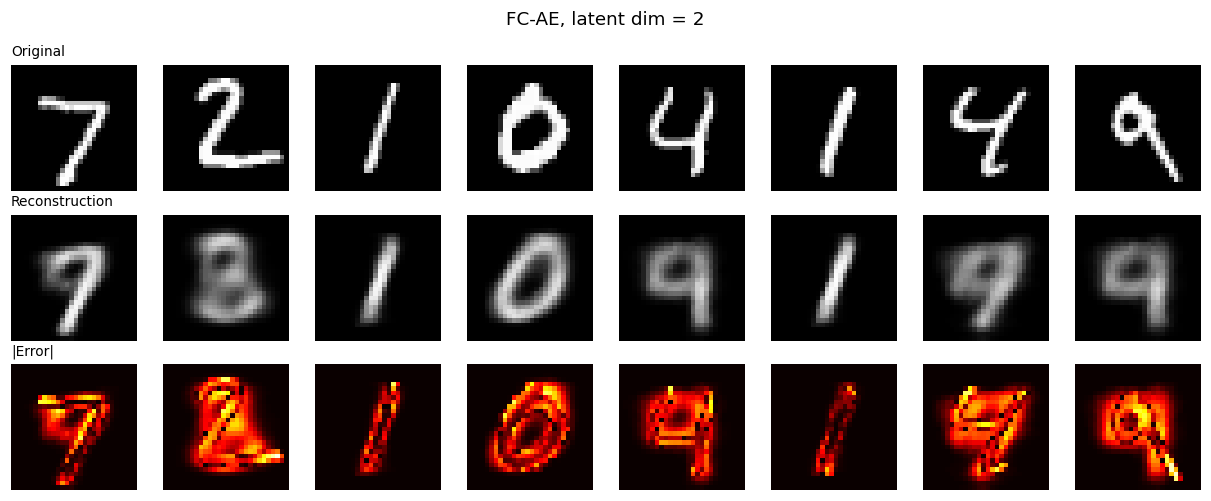

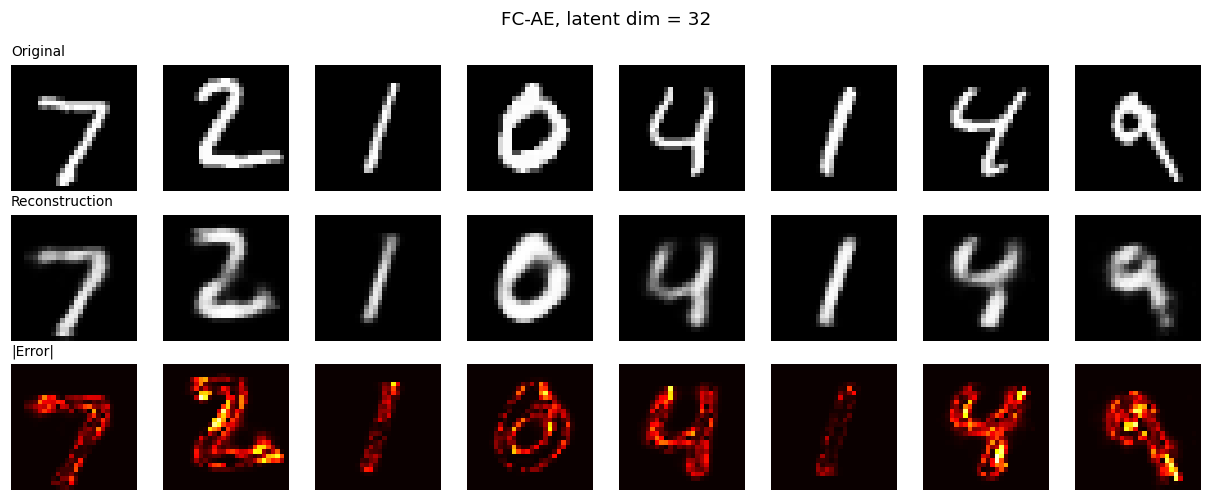

,MSE,SSIM,Params
Latent dimension,,,
2,0.04516,0.46630,210130
8,0.02665,0.68396,210520
16,0.02225,0.73857,211040
32,0.01948,0.76600,212080


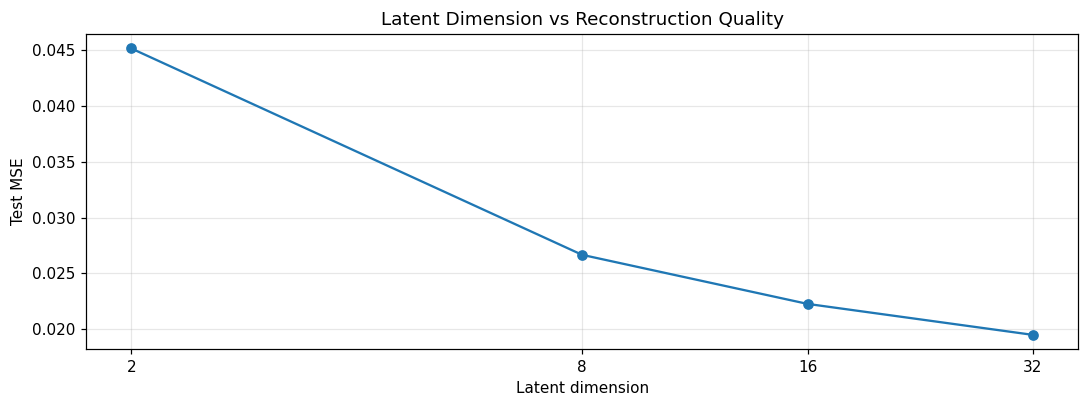

In [19]:
rows = []
for dz in [2, 8, 16, 32]:
    tf.random.set_seed(SEED)
    m_ = build_fc_ae(dz)
    fit_timed(m_, flat(x_fit), flat(x_fit), epochs=EPOCHS, batch_size=BATCH, shuffle=True)
    xh = m_.predict(flat(x_test), verbose=0).reshape(-1, 28, 28, 1)
    r = evaluate_recon(x_test, xh)
    rows.append({"Latent dimension": dz, "MSE": r["MSE"], "SSIM": r["SSIM"], "Params": m_.count_params()})
    if dz in (2, 32): show_recon(x_test, xh, n=8, title=f"FC-AE, latent dim = {dz}")
lat_tab = pd.DataFrame(rows).set_index("Latent dimension")
display(lat_tab.round(5))
plt.figure(figsize=(10, 3.8))


plt.plot(lat_tab.index, lat_tab["MSE"], "o-")
plt.xlabel("Latent dimension")
plt.ylabel("Test MSE")
plt.xscale("log", base=2)
plt.xticks(lat_tab.index, lat_tab.index)
plt.title("Latent Dimension vs Reconstruction Quality")
plt.tight_layout()
plt.show()

In [20]:
final = pd.DataFrame(results).T[["MSE", "MAE", "SSIM", "Params", "Time (s)"]]
final["Params"] = final["Params"].astype(int)
display(final.round(5))
final.round(5).to_csv("experiment7_results.csv")


,MSE,MAE,SSIM,Params,Time (s)
FC Autoencoder,0.02049,0.05540,0.75777,211040,15.69070
Conv. Autoencoder,0.00259,0.01504,0.97377,74497,19.41857
Denoising CAE (sigma=0.2),0.00437,0.02054,0.94758,74497,22.58298
VAE,0.04279,0.09980,0.50302,485957,26.58571


In [21]:
rows = []
for dz in [4, 8, 16, 32]:
    m_ = build_cae(dz)
    fit_timed(m_, x_fit, x_fit, epochs=EPOCHS, batch_size=BATCH, shuffle=True)
    r = evaluate_recon(x_test, m_.predict(x_test, verbose=0))
    rows.append({"Latent dim": dz, **r, "Params": m_.count_params()})
display(pd.DataFrame(rows).set_index("Latent dim").round(5))

,MSE,MAE,SSIM,Params
Latent dim,,,,
4,0.03345,0.07890,0.64233,102725
8,0.02012,0.05236,0.78155,127817
16,0.01079,0.03383,0.88446,178001
32,0.00598,0.02367,0.93624,278369


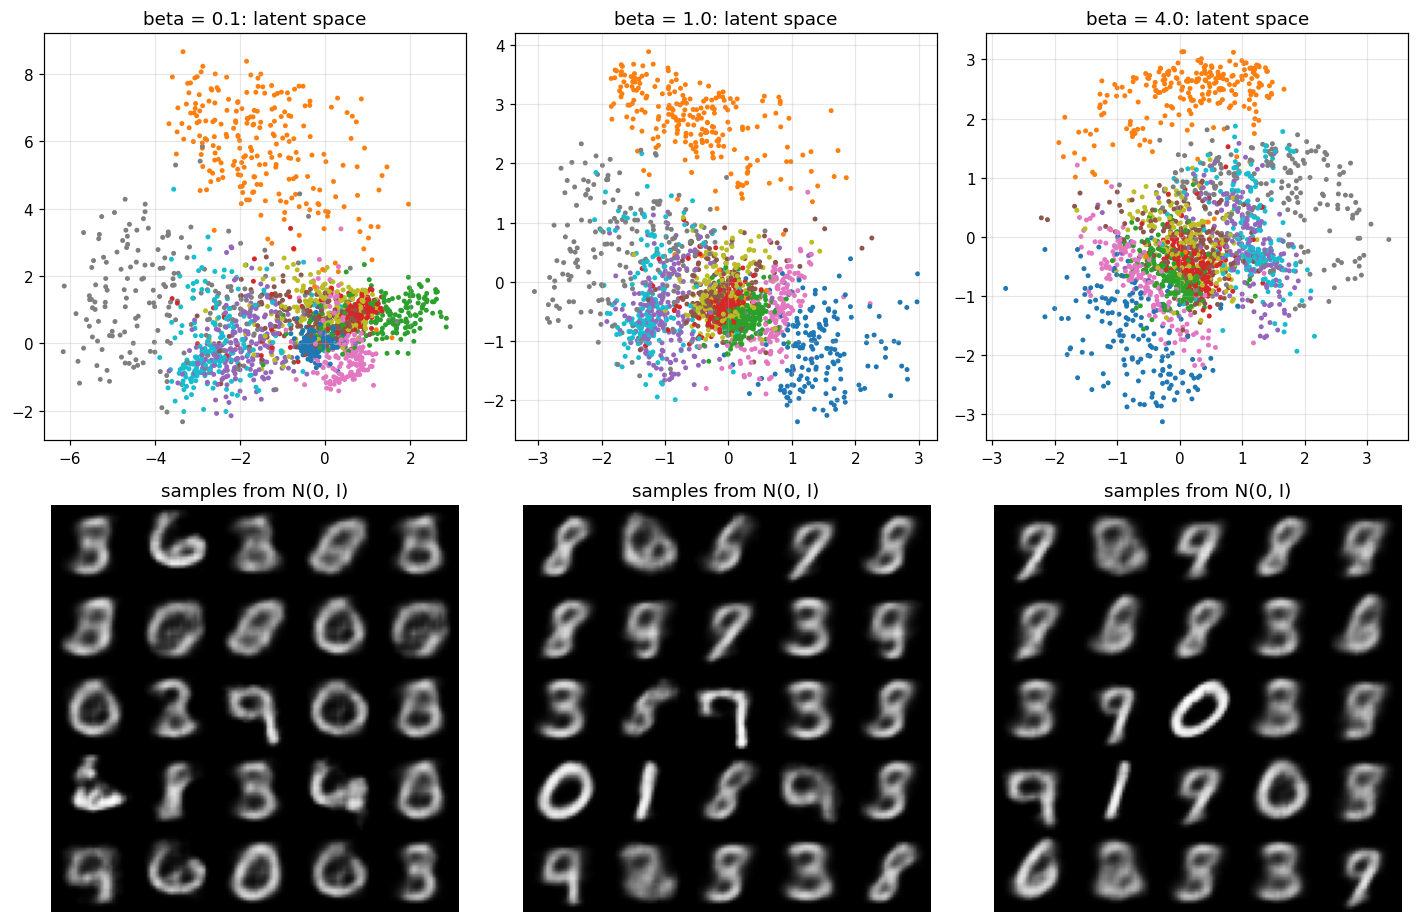

,Rec loss,KL,MSE,MAE,SSIM
beta,,,,,
0.1,151.2635,10.6594,0.0449,0.1016,0.4918
1.0,150.4836,5.4612,0.0440,0.1038,0.4745
4.0,154.2651,3.9420,0.0448,0.1059,0.4717


In [22]:
fig, ax = plt.subplots(2, 3, figsize=(13, 8.5)); rows = []
for j, beta in enumerate([0.1, 1.0, 4.0]):
    v, h, _ = train_vae(2, beta, epochs=20)
    mu, _, _ = v.encoder.predict(x_test, verbose=0)
    r = evaluate_recon(x_test, v.decoder.predict(mu, verbose=0))
    ev = v.evaluate(x_test, x_test, verbose=0, return_dict=True)
    rows.append({"beta": beta, "Rec loss": ev["rec_loss"], "KL": ev["kl_loss"], **r})
    ax[0, j].scatter(mu[:, 0], mu[:, 1], c=y_test, cmap="tab10", s=5); ax[0, j].set_title(f"beta = {beta}: latent space")
    z = np.random.default_rng(1).normal(size=(25, 2)).astype("float32")
    g_ = v.decoder.predict(z, verbose=0).reshape(5, 5, 28, 28).transpose(0, 2, 1, 3).reshape(140, 140)
    ax[1, j].imshow(g_, cmap="gray"); ax[1, j].axis("off"); ax[1, j].set_title("samples from N(0, I)")
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index("beta").round(4))

VAE dz=8: {'MSE': 0.0188, 'MAE': 0.0508, 'SSIM': 0.7929, 'Rec': 95.7537, 'KL': 16.6751}
VAE dz=2: {'MSE': 0.0428, 'MAE': 0.0998, 'SSIM': 0.503, 'Rec': np.float64(147.341), 'KL': np.float64(6.0585)}


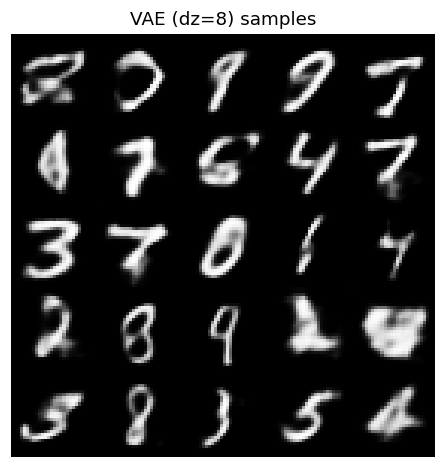

In [23]:
vae8, h8, _ = train_vae(8, 1.0)
mu8, _, _ = vae8.encoder.predict(x_test, verbose=0)
r8 = evaluate_recon(x_test, vae8.decoder.predict(mu8, verbose=0)); ev8 = vae8.evaluate(x_test, x_test, verbose=0, return_dict=True)
print("VAE dz=8:", {k: round(v, 4) for k, v in {**r8, "Rec": ev8["rec_loss"], "KL": ev8["kl_loss"]}.items()})
print("VAE dz=2:", {k: round(v, 4) for k, v in {**results['VAE'], 'Rec': vae_tab['Reconstruction loss'], 'KL': vae_tab['KL loss']}.items() if k in ('MSE', 'MAE', 'SSIM', 'Rec', 'KL')})
z = np.random.default_rng(3).normal(size=(25, 8)).astype("float32")
g_ = vae8.decoder.predict(z, verbose=0).reshape(5, 5, 28, 28).transpose(0, 2, 1, 3).reshape(140, 140)
plt.figure(figsize=(5, 5)); plt.imshow(g_, cmap="gray"); plt.axis("off"); plt.title("VAE (dz=8) samples"); plt.show()

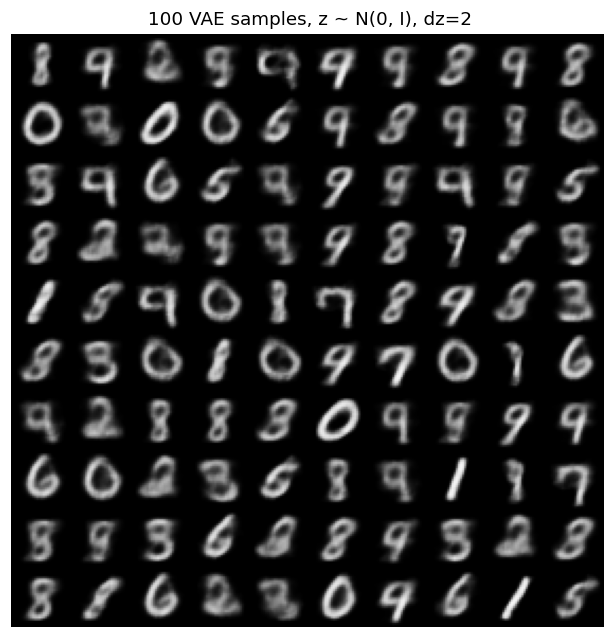

mean pairwise pixel-MSE across the 100 samples: 0.0435 (higher = more visually diverse samples)
Look at the grid above and count roughly how many of the 10 digit shapes (0-9) are recognizably represented, and whether any region is dominated by a single digit or by ambiguous/blurred shapes (usually the areas between digit clusters in Plot 6).


In [26]:
n_side = 10
rng = np.random.default_rng(11)
z_grid = rng.normal(size=(n_side * n_side, 2)).astype("float32")
gen100 = vae.decoder.predict(z_grid, verbose=0).reshape(n_side, n_side, 28, 28)
canvas = gen100.transpose(0, 2, 1, 3).reshape(n_side * 28, n_side * 28)

plt.figure(figsize=(7, 7))
plt.imshow(canvas, cmap="gray", vmin=0, vmax=1); plt.axis("off")
plt.title(f" {n_side * n_side} VAE samples, z ~ N(0, I), dz=2")
plt.show()

flat_gen = gen100.reshape(-1, 28 * 28)
from itertools import combinations
pw = [np.mean((flat_gen[i] - flat_gen[j]) ** 2) for i, j in combinations(range(len(flat_gen)), 2)]
print(f"mean pairwise pixel-MSE across the {len(flat_gen)} samples: {np.mean(pw):.4f} "
      f"(higher = more visually diverse samples)")
print("Look at the grid above and count roughly how many of the 10 digit shapes (0-9) "
      "are recognizably represented, and whether any region is dominated by a single digit "
      "or by ambiguous/blurred shapes (usually the areas between digit clusters in Plot 6).")

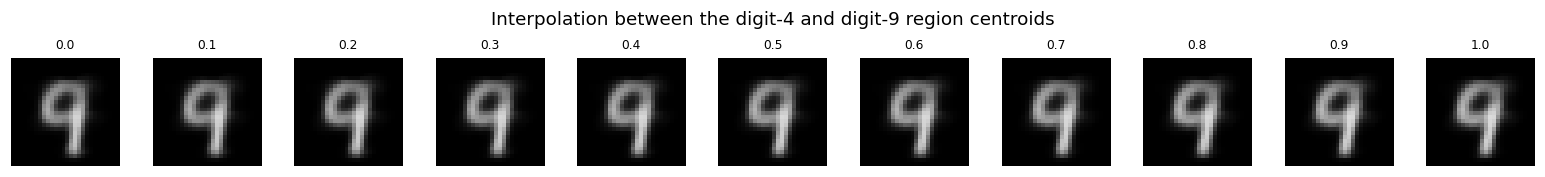

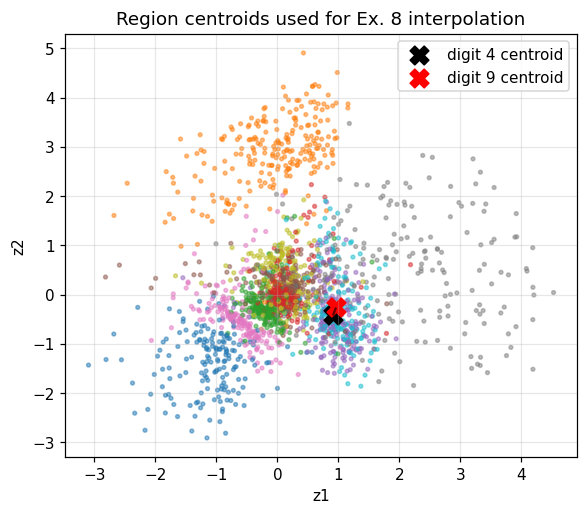

In [27]:
def interpolate_regions(digit_a, digit_b, steps=11):
    zA = mu_te[y_test == digit_a].mean(axis=0)   # region centroid for digit_a
    zB = mu_te[y_test == digit_b].mean(axis=0)   # region centroid for digit_b
    alphas = np.linspace(0, 1, steps)
    zs = np.array([(1 - a) * zA + a * zB for a in alphas], dtype="float32")
    return alphas, vae.decoder.predict(zs, verbose=0), zA, zB

DIGIT_A, DIGIT_B = 4, 9   # change these to any two digits you want to compare
alphas, imgs, zA, zB = interpolate_regions(DIGIT_A, DIGIT_B)

fig, ax = plt.subplots(1, len(alphas), figsize=(1.3 * len(alphas), 1.6))
for a, img, al in zip(ax, imgs, alphas):
    a.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); a.axis("off"); a.set_title(f"{al:.1f}", fontsize=8)
fig.suptitle(f"Interpolation between the digit-{DIGIT_A} and digit-{DIGIT_B} region centroids")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(mu_te[:, 0], mu_te[:, 1], c=y_test, cmap="tab10", s=6, alpha=0.5)
plt.scatter(*zA, c="black", marker="X", s=150, label=f"digit {DIGIT_A} centroid")
plt.scatter(*zB, c="red", marker="X", s=150, label=f"digit {DIGIT_B} centroid")
plt.plot([zA[0], zB[0]], [zA[1], zB[1]], "k--", alpha=0.6)
plt.xlabel("z1"); plt.ylabel("z2"); plt.legend()
plt.title("Region centroids used for Ex. 8 interpolation")
plt.show()